In [1]:
# Dự báo doanh thu theo tháng bằng Linear Regression
# Nội dung notebook:
# - Chuẩn bị dữ liệu dự báo
# - Xây dựng mô hình Linear Regression
# - Đánh giá mô hình
# - Lưu mô hình và kết quả dự báo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("..\Data\Superstore Sale Dataset.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
#5.1 Chuẩn bị dữ liệu dự báo
# Tổng hợp Sales theo tháng
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"].sum().reset_index()
monthly_sales.columns = ["MonthStart", "Sales"]

monthly_sales.head()

,MonthStart,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


In [5]:
print("Số dòng dữ liệu theo tháng:", len(monthly_sales))
monthly_sales.tail()

Số dòng dữ liệu theo tháng: 48


,MonthStart,Sales
43,2017-08-01,63120.8880
44,2017-09-01,87866.6520
45,2017-10-01,77776.9232
46,2017-11-01,118447.8250
47,2017-12-01,83829.3188


In [7]:
monthly_sales["TimeIndex"] = np.arange(len(monthly_sales))

monthly_sales.head()

,MonthStart,Sales,TimeIndex
0,2014-01-01,14236.895,0
1,2014-02-01,4519.892,1
2,2014-03-01,55691.009,2
3,2014-04-01,28295.345,3
4,2014-05-01,23648.287,4


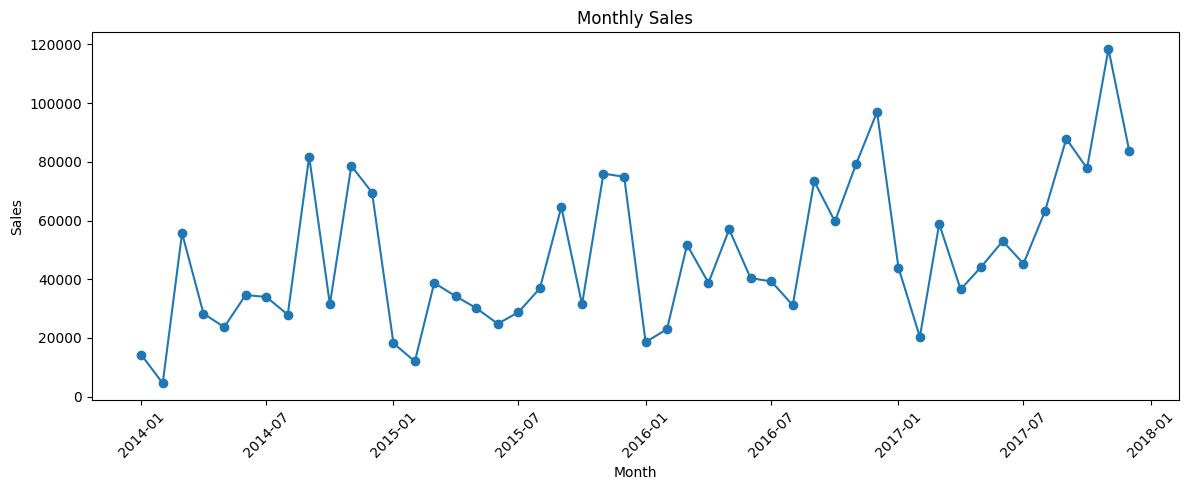

In [8]:
#Biểu đồ doanh thu đầu tháng
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["MonthStart"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
X = monthly_sales[["TimeIndex"]]
y = monthly_sales["Sales"]

In [10]:
train_size = int(len(monthly_sales) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 38
Test size: 10


In [11]:
# 5.2 Xây dựng mô hình
# Huấn luyện Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print("Hệ số góc:", model.coef_[0])
print("Hệ số chặn:", model.intercept_)

Hệ số góc: 699.5466081299924
Hệ số chặn: 29907.285446963568


In [15]:
y_pred = model.predict(X_test)

pred_df = pd.DataFrame({
    "MonthStart": monthly_sales["MonthStart"].iloc[train_size:].values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

pred_df.head()

,MonthStart,Actual,Predicted
0,2017-03-01,58872.3528,56490.056556
1,2017-04-01,36521.5361,57189.603164
2,2017-05-01,44261.1102,57889.149772
3,2017-06-01,52981.7257,58588.696380
4,2017-07-01,45264.4160,59288.242988


In [ ]:
#5.3 Đánh giá mô hình
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.4f}")   

MAE  = 18041.64
RMSE = 23416.38
R²   = 0.0342


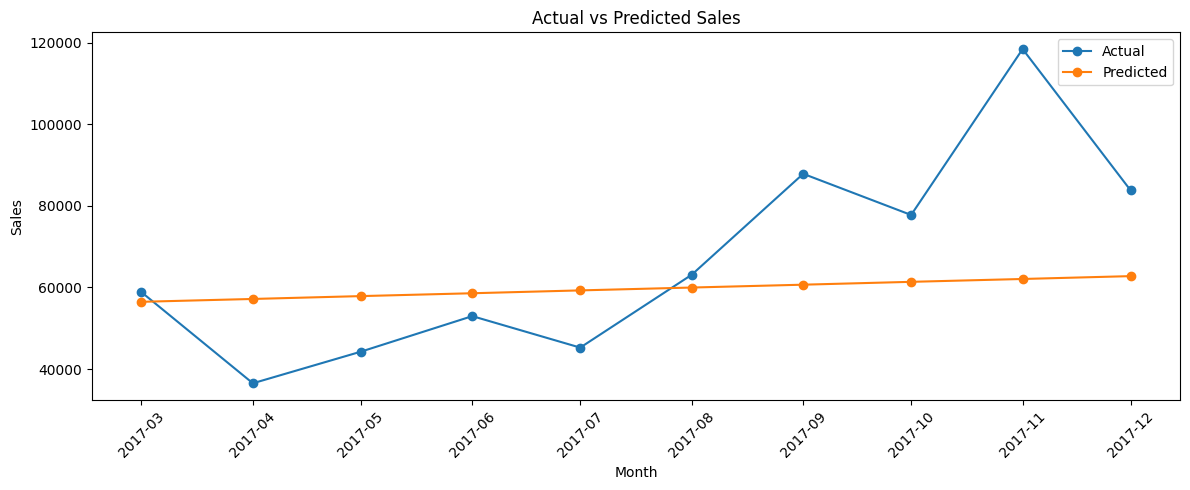

In [15]:
#Biểu đồ Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(pred_df["MonthStart"], pred_df["Actual"], marker="o", label="Actual")
plt.plot(pred_df["MonthStart"], pred_df["Predicted"], marker="o", label="Predicted")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

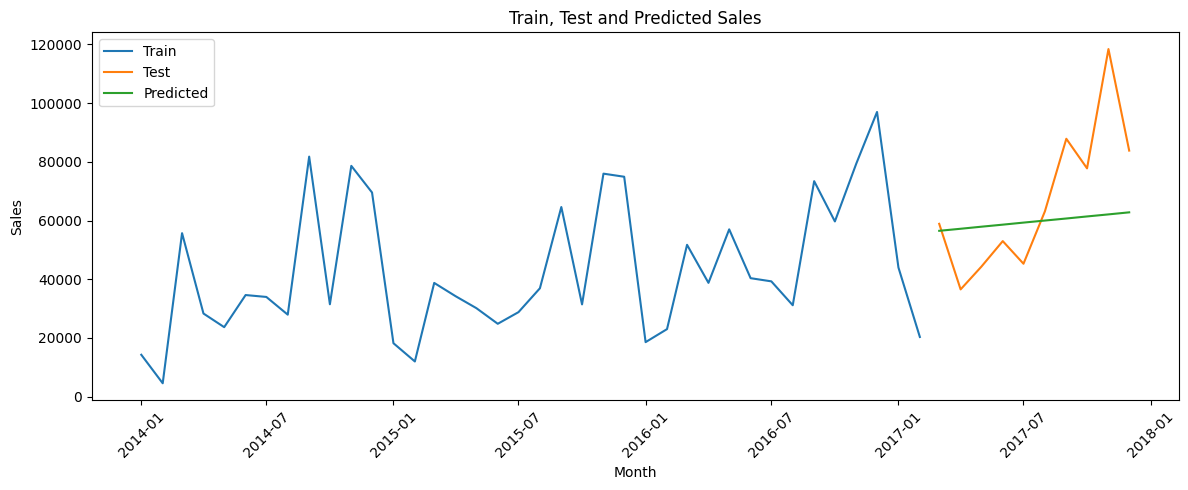

In [ ]:

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales["MonthStart"][:train_size], y_train, label="Train")
plt.plot(monthly_sales["MonthStart"][train_size:], y_test, label="Test")
plt.plot(monthly_sales["MonthStart"][train_size:], y_pred, label="Predicted")

plt.title("Train, Test and Predicted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
print("NHẬN XÉT MÔ HÌNH:")
print(f"- MAE = {mae:.2f}")
print(f"- RMSE = {rmse:.2f}")
print(f"- R² = {r2:.4f}")

if r2 > 0.7:
    print("- Mô hình có mức độ phù hợp tương đối tốt với dữ liệu.")
elif r2 > 0.4:
    print("- Mô hình có khả năng mô tả xu hướng ở mức trung bình.")
else:
    print("- Mô hình chỉ phản ánh xu hướng ở mức hạn chế, cần cải tiến thêm.")

NHẬN XÉT MÔ HÌNH:
- MAE = 18041.64
- RMSE = 23416.38
- R² = 0.0342
- Mô hình chỉ phản ánh xu hướng ở mức hạn chế, cần cải tiến thêm.


In [18]:
#5.4 Lưu mô hình
with open("linear_regression_sales_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Đã lưu model thành công.")

Đã lưu model thành công.


In [19]:
pred_df.to_csv("sales_prediction_results.csv", index=False, encoding="utf-8-sig")
print("Đã lưu file kết quả dự báo.")

Đã lưu file kết quả dự báo.


In [20]:
pred_df.tail()

,MonthStart,Actual,Predicted
5,2017-08-01,63120.8880,59987.789597
6,2017-09-01,87866.6520,60687.336205
7,2017-10-01,77776.9232,61386.882813
8,2017-11-01,118447.8250,62086.429421
9,2017-12-01,83829.3188,62785.976029


In [23]:
#Dự báo 6 tháng tiếp theo
future_steps = 6
last_index = monthly_sales["TimeIndex"].max()

future_index = np.arange(last_index + 1, last_index + 1 + future_steps)
future_pred = model.predict(future_index.reshape(-1, 1))

last_date = monthly_sales["MonthStart"].max()
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=future_steps, freq="MS")

future_df = pd.DataFrame({
    "MonthStart": future_dates,
    "PredictedSales": future_pred
})

future_df

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,MonthStart,PredictedSales
0,2018-01-01,63485.522637
1,2018-02-01,64185.069245
2,2018-03-01,64884.615853
3,2018-04-01,65584.162462
4,2018-05-01,66283.709070
5,2018-06-01,66983.255678


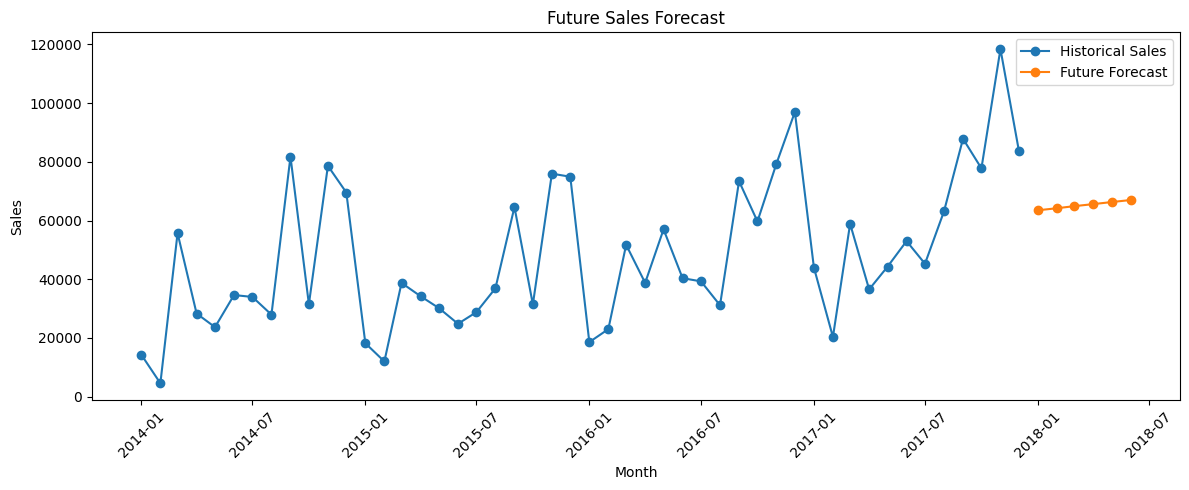

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["MonthStart"], monthly_sales["Sales"], marker="o", label="Historical Sales")
plt.plot(future_df["MonthStart"], future_df["PredictedSales"], marker="o", label="Future Forecast")
plt.title("Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
future_df.to_csv("future_sales_forecast.csv", index=False, encoding="utf-8-sig")
print("Đã lưu file dự báo tương lai.")

Đã lưu file dự báo tương lai.
